In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Przygotowanie danych

### Pobranie danych

In [3]:
signal = np.loadtxt("assets/signal.csv")

### Wygenerowanie danych

In [8]:
import website.impuls_simulator as impuls_simulator
B=15
fs=25000
varsize=25000
fmod=30
f_center=2000
bandwidth=500
shift=0
sigma = 5
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)

## Szereg w czasie

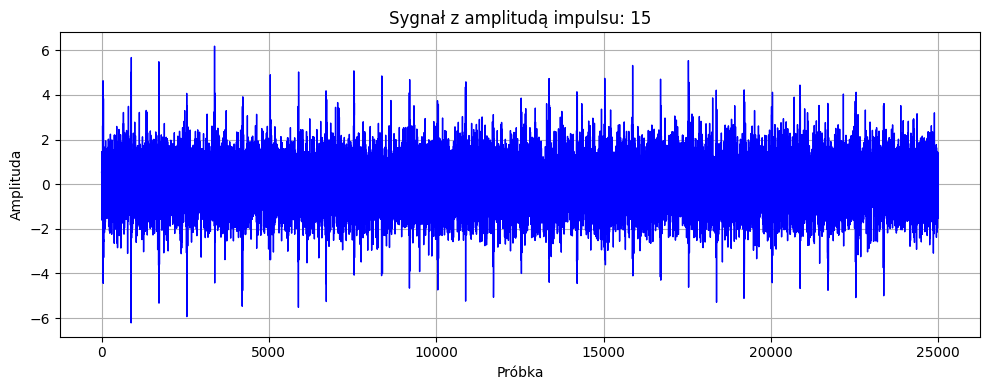

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(signal, color='blue', linewidth=1)
plt.title(f"Sygnał z amplitudą impulsu: {B}")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()

## Spektrogram

### Obliczenie krótkoczasowej transformaty Fouriera

In [32]:
fs = 25000
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
print(array_freq)


[    0.         97.65625   195.3125    292.96875   390.625     488.28125
   585.9375    683.59375   781.25      878.90625   976.5625   1074.21875
  1171.875    1269.53125  1367.1875   1464.84375  1562.5      1660.15625
  1757.8125   1855.46875  1953.125    2050.78125  2148.4375   2246.09375
  2343.75     2441.40625  2539.0625   2636.71875  2734.375    2832.03125
  2929.6875   3027.34375  3125.       3222.65625  3320.3125   3417.96875
  3515.625    3613.28125  3710.9375   3808.59375  3906.25     4003.90625
  4101.5625   4199.21875  4296.875    4394.53125  4492.1875   4589.84375
  4687.5      4785.15625  4882.8125   4980.46875  5078.125    5175.78125
  5273.4375   5371.09375  5468.75     5566.40625  5664.0625   5761.71875
  5859.375    5957.03125  6054.6875   6152.34375  6250.       6347.65625
  6445.3125   6542.96875  6640.625    6738.28125  6835.9375   6933.59375
  7031.25     7128.90625  7226.5625   7324.21875  7421.875    7519.53125
  7617.1875   7714.84375  7812.5      7910.15625  8

### Wyrysowanie wykresu

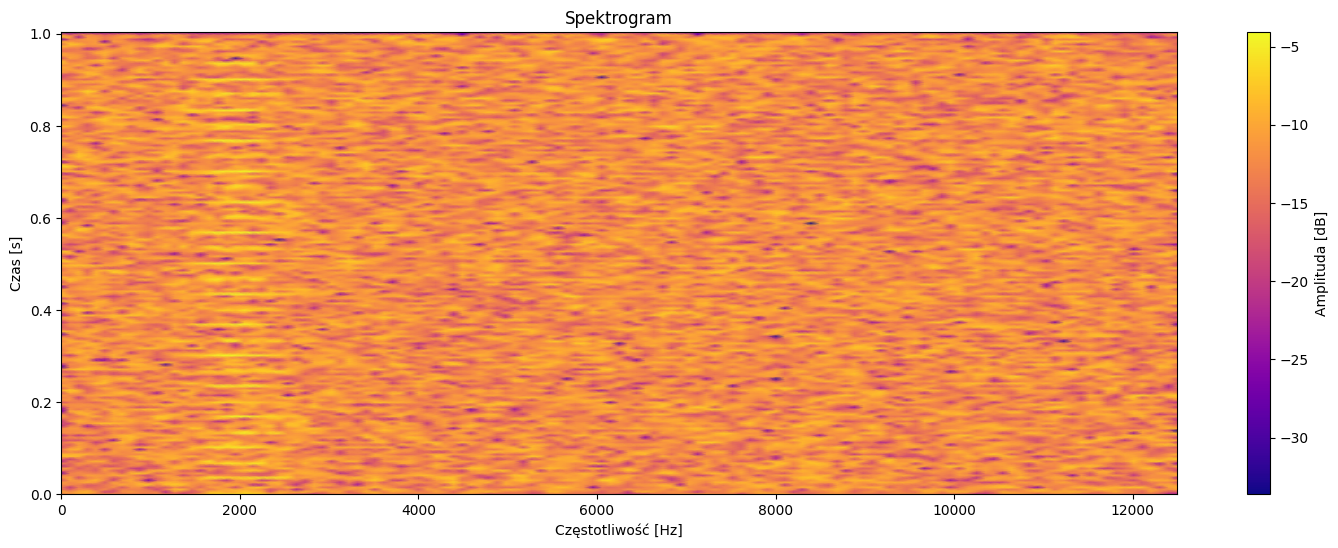

In [27]:

plt.figure(figsize=(18, 6))
plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram')
plt.colorbar(label='Amplituda [dB]')
plt.show()

# Selektory

In [8]:
import ifb_selectors as selector

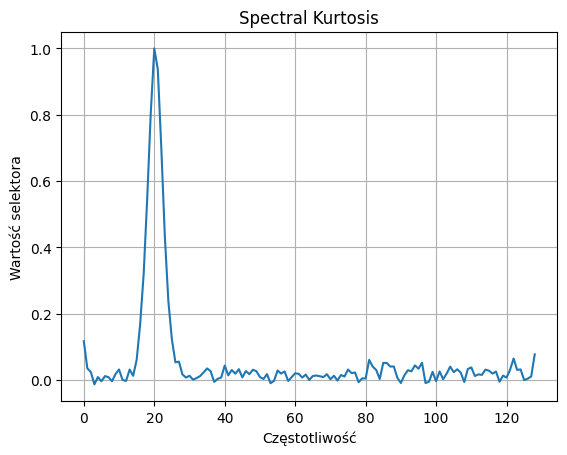

In [9]:
sk_results = selector.SK(Zxx)
fig, axes = plt.subplots()
axes.plot(sk_results)
axes.set_title("Spectral Kurtosis")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

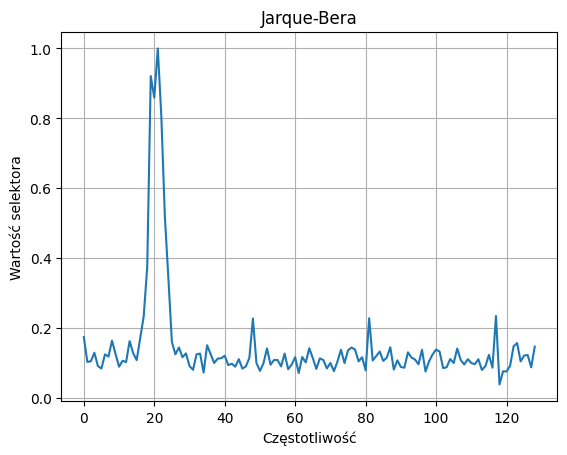

In [10]:
jb_results = selector.JB(Zxx)
fig, axes = plt.subplots()
axes.plot(jb_results)
axes.set_title("Jarque-Bera")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

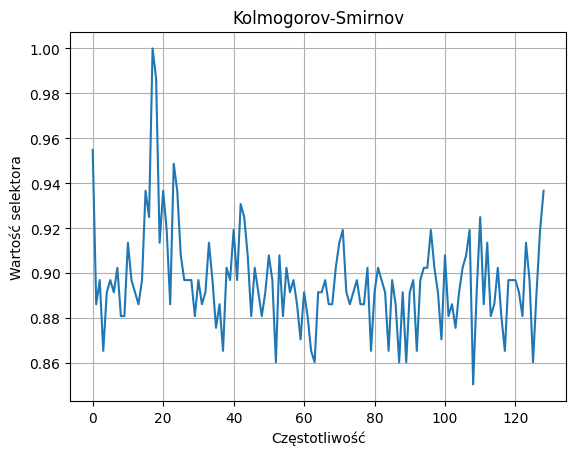

In [11]:
kss_results = selector.KSS(Zxx)
fig, axes = plt.subplots()
axes.plot(kss_results)
axes.set_title("Kolmogorov-Smirnov")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

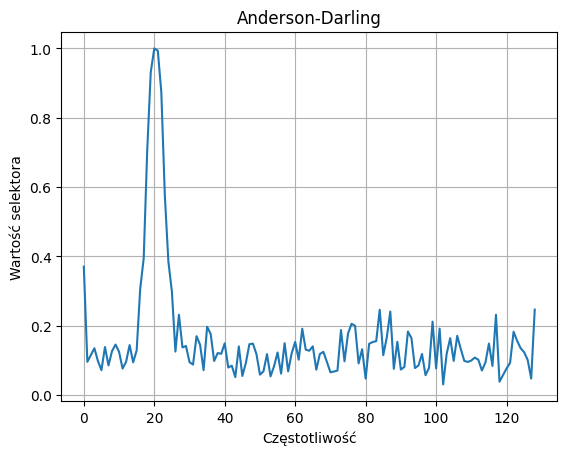

In [12]:
ad_results = selector.AD(Zxx)
fig, axes = plt.subplots()
axes.plot(ad_results)
axes.set_title("Anderson-Darling")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

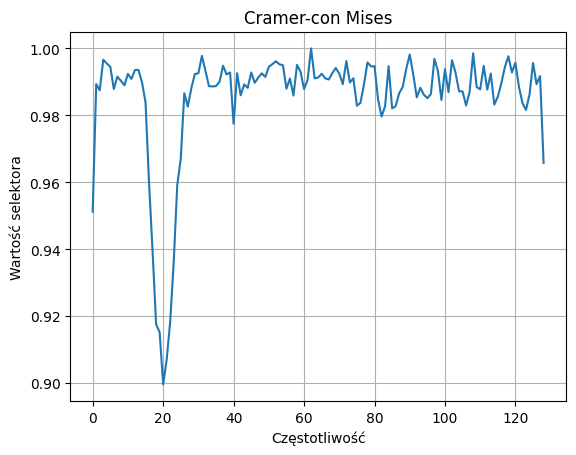

In [13]:
cvm_results = selector.CVM(Zxx)
fig, axes = plt.subplots()
axes.plot(cvm_results)
axes.set_title("Cramer-con Mises")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

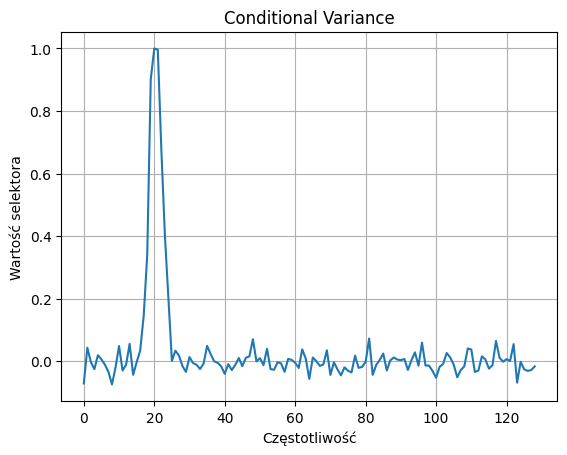

In [14]:
cvs_results = selector.CVS(Zxx)
fig, axes = plt.subplots()
axes.plot(cvs_results)
axes.set_title("Conditional Variance")
axes.set_xlabel("Częstotliwość")
axes.set_ylabel("Wartość selektora")
axes.grid()
plt.show()

## Faktyczne obliczenie wszystkich selektorów


[ 0.16000994  0.03429137  0.03366786  0.0408901   0.01479304  0.01371358
  0.02093266  0.02438883  0.02640005  0.03314342  0.01591757  0.01867602
  0.05199714  0.07409967  0.07884293  0.1275612   0.17186774  0.44677169
  0.81116414  0.89797913  0.91365262  1.          0.80006086  0.41004377
  0.25353593  0.19779442  0.08959007  0.04337278  0.03394004  0.01366929
  0.02572325 -0.00573232  0.00366649  0.03805887  0.03620513  0.05373857
  0.04098654  0.02475282  0.02554001  0.02338774  0.02545814  0.02490421
 -0.01316657 -0.00196939  0.00351436  0.05249895  0.01427724  0.01283063
  0.00578262  0.03822846  0.03788215 -0.00254063  0.03182156  0.04471569
  0.03137135  0.0287111   0.06004516  0.03584738  0.01602261  0.03778677
  0.01567715  0.01998633  0.06570751  0.06689599  0.01175623  0.05691537
  0.01655442 -0.01433362  0.02613767  0.07453738  0.10839499  0.02617876
  0.01950275  0.03593533  0.06367229  0.05914652  0.02316259  0.02327786
  0.02607878  0.01663094  0.03298391  0.0347425   0

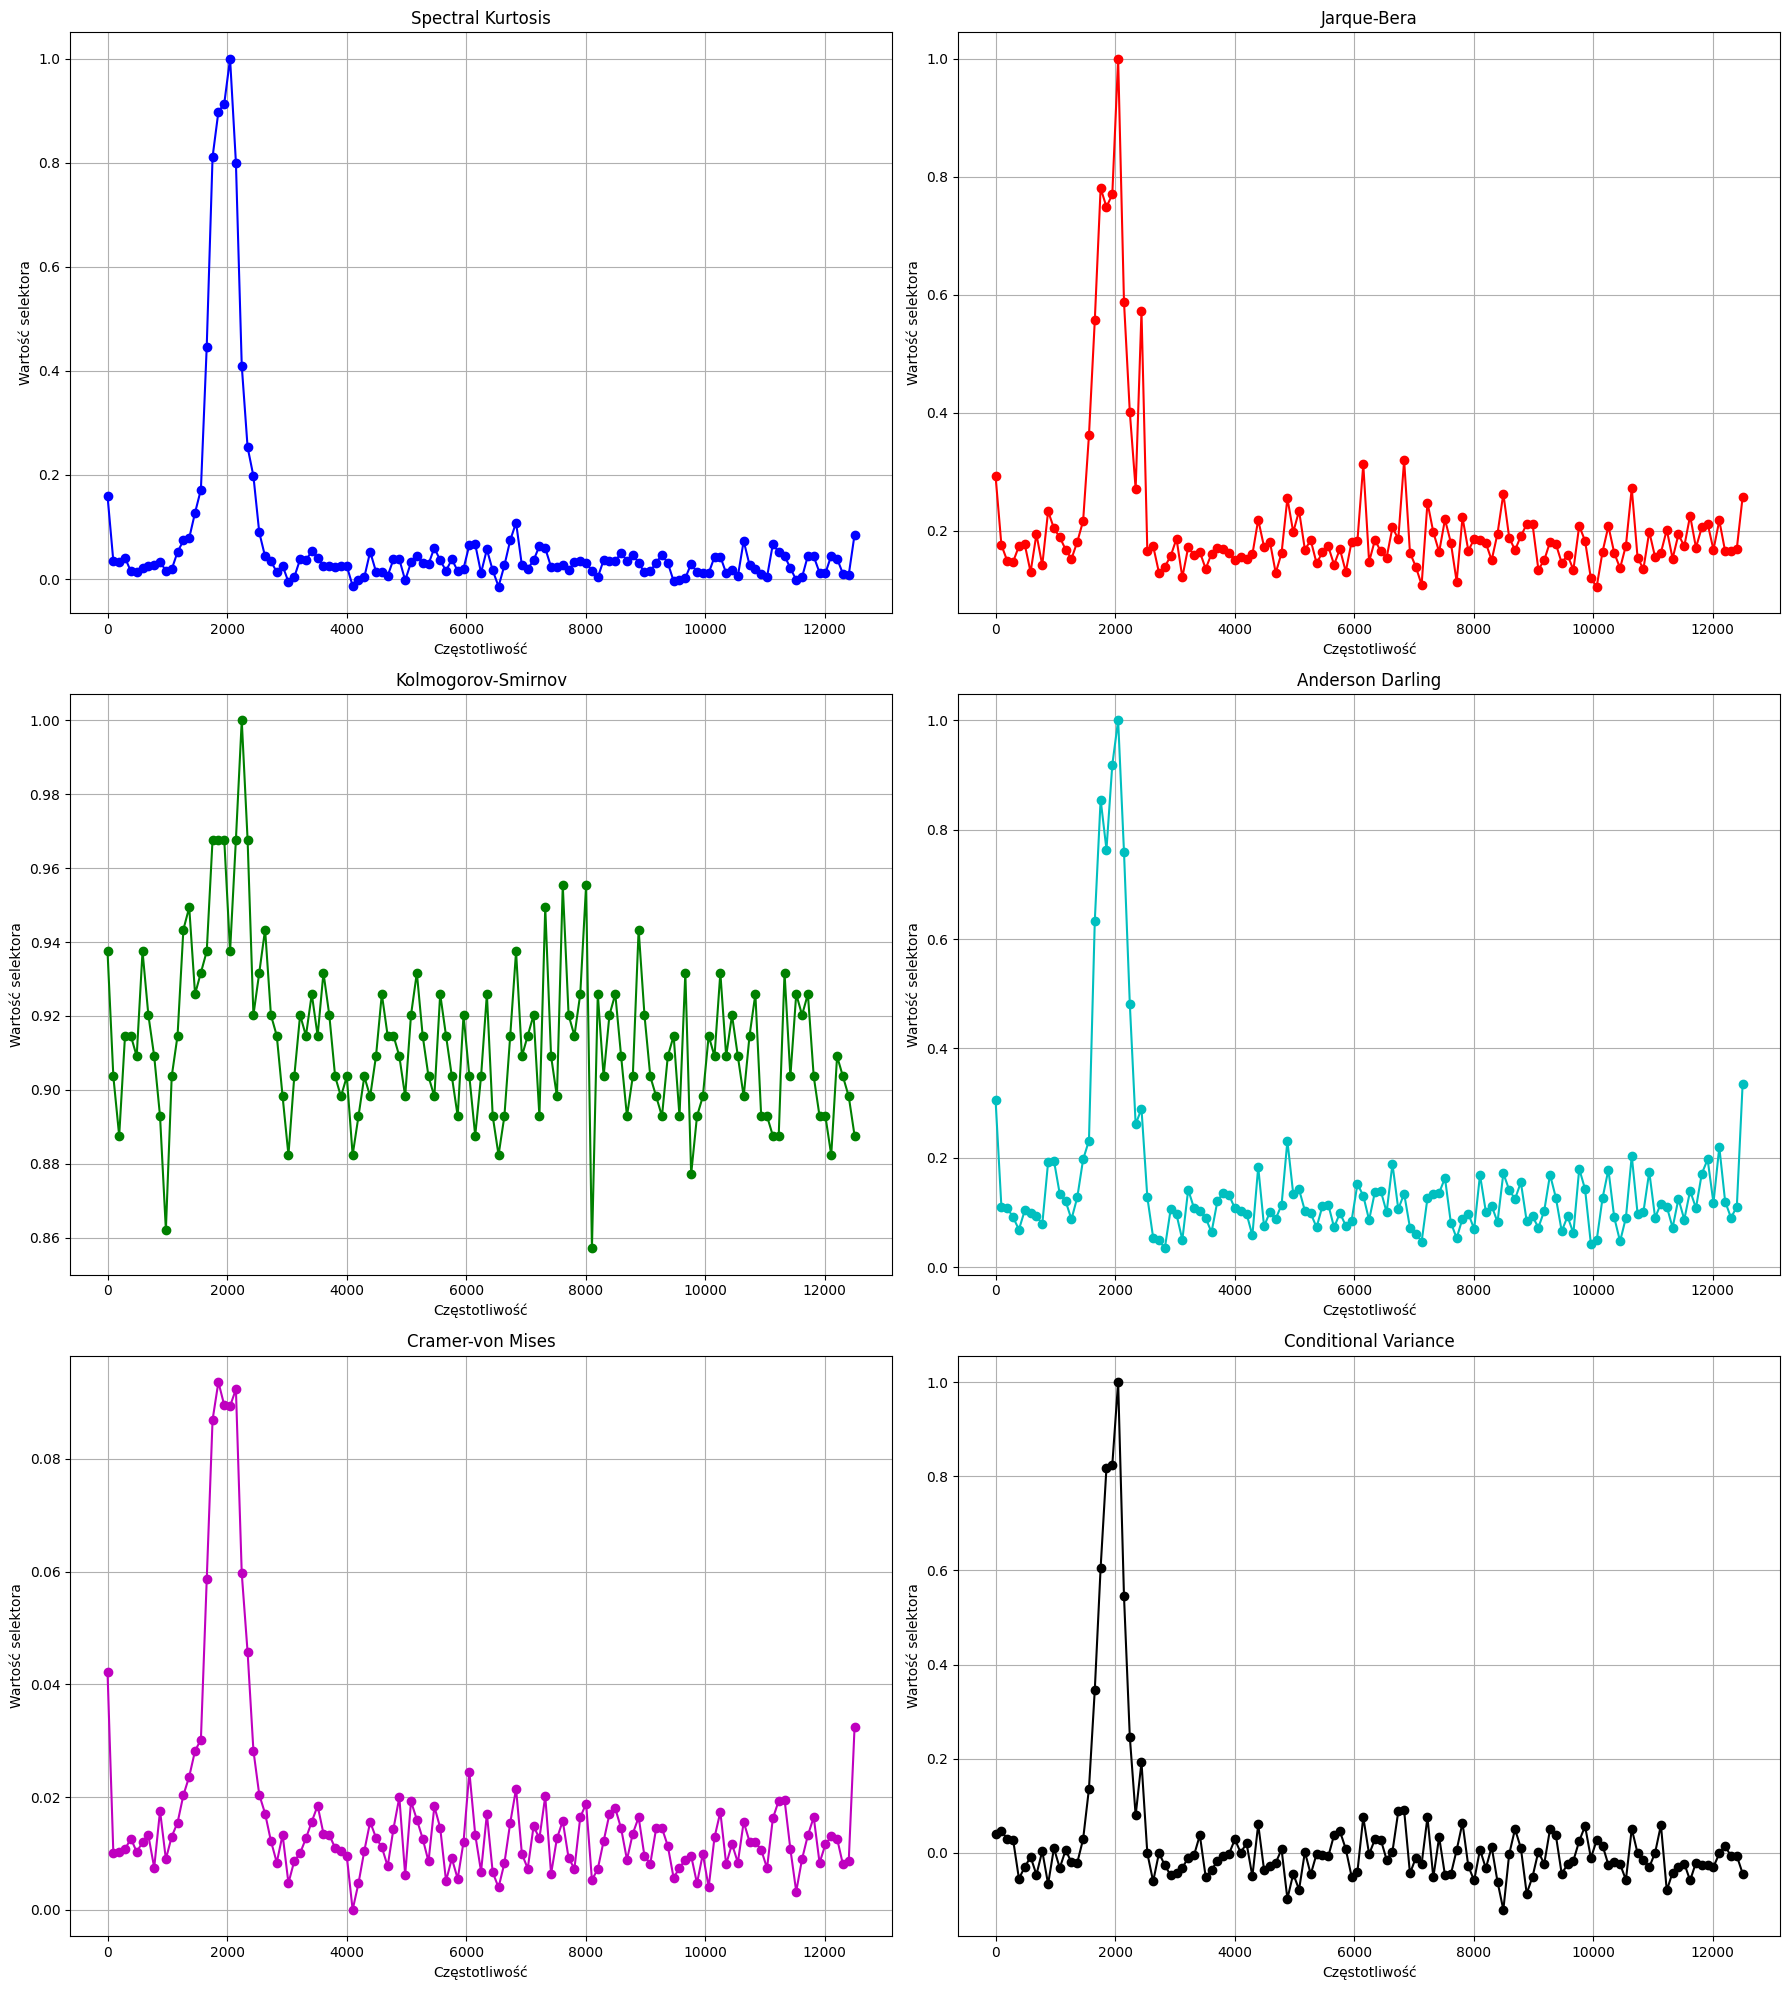

In [35]:
import ifb_selectors as selector

sk_results = selector.SK(Zxx)
jb_results = selector.JB(Zxx)
kss_results = selector.KSS(Zxx)
ad_results = selector.AD(Zxx)
cvm_results = 1-selector.CVM(Zxx)
cvs_results = selector.CVS(Zxx)
print(sk_results)

fig, axes = plt.subplots(3,2,figsize=(18,20))
axes[0,0].plot(array_freq,sk_results,'bo-')
axes[0,0].set_title("Spectral Kurtosis")
axes[0,0].set_xlabel("Częstotliwość")
axes[0,0].set_ylabel("Wartość selektora")

axes[0,1].plot(array_freq,jb_results,'ro-')
axes[0,1].set_title("Jarque-Bera")
axes[0,1].set_xlabel("Częstotliwość")
axes[0,1].set_ylabel("Wartość selektora")

axes[1,0].plot(array_freq, kss_results,'go-')
axes[1,0].set_title("Kolmogorov-Smirnov")
axes[1,0].set_xlabel("Częstotliwość")
axes[1,0].set_ylabel("Wartość selektora")

axes[1,1].plot(array_freq, ad_results,'co-')
axes[1,1].set_title("Anderson Darling")
axes[1,1].set_xlabel("Częstotliwość")
axes[1,1].set_ylabel("Wartość selektora")

axes[2,0].plot(array_freq, cvm_results,'mo-')
axes[2,0].set_title("Cramer-von Mises")
axes[2,0].set_xlabel("Częstotliwość")
axes[2,0].set_ylabel("Wartość selektora")

axes[2,1].plot(array_freq, cvs_results,'ko-')
axes[2,1].set_title("Conditional Variance")
axes[2,1].set_xlabel("Częstotliwość")
axes[2,1].set_ylabel("Wartość selektora")

axes[0,0].grid()
axes[0,1].grid()
axes[1,0].grid()
axes[1,1].grid()
axes[2,0].grid()
axes[2,1].grid()

plt.tight_layout()
plt.show()

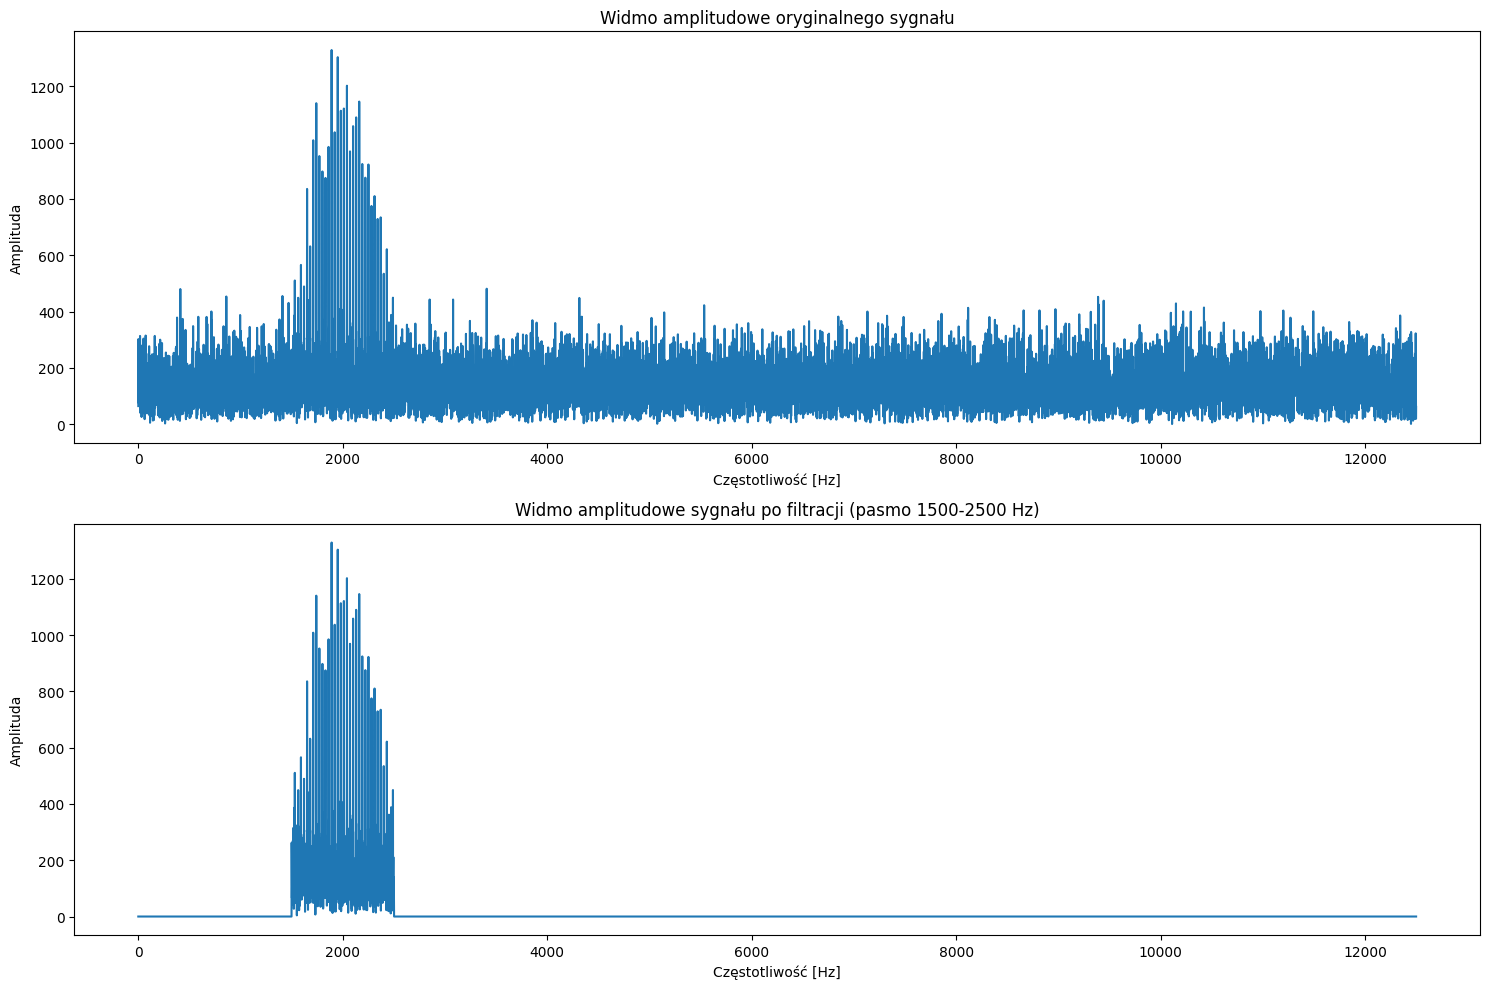

In [16]:
def bandpass_filter(signal, fs, f_low, f_high):
    # Wykonanie FFT
    fft_signal = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    
    # Tworzenie maski dla wybranego pasma
    mask = (abs(freqs) >= f_low) & (abs(freqs) <= f_high)
    
    # Aplikacja maski (wyzerowanie składowych poza wybranym pasmem)
    fft_signal_filtered = fft_signal.copy()
    fft_signal_filtered[~mask] = 0
    
    # Odwrotna transformata Fouriera
    filtered_signal = np.real(np.fft.ifft(fft_signal_filtered))
    
    return filtered_signal, freqs, fft_signal, fft_signal_filtered

# Przykład użycia - filtrowanie pasma 1500-2500 Hz
f_low = 1500  # dolna częstotliwość pasma przepustowego
f_high = 2500 # górna częstotliwość pasma przepustowego

filtered_signal, freqs, fft_orig, fft_filtered = bandpass_filter(signal, fs, f_low, f_high)

# Wizualizacja
plt.figure(figsize=(15, 10))

# Oryginalny sygnał w dziedzinie częstotliwości
plt.subplot(2, 1, 1)
plt.plot(freqs[freqs >= 0], np.abs(fft_orig[freqs >= 0]))
plt.title('Widmo amplitudowe oryginalnego sygnału')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Amplituda')

# Przefiltrowany sygnał w dziedzinie częstotliwości
plt.subplot(2, 1, 2)
plt.plot(freqs[freqs >= 0], np.abs(fft_filtered[freqs >= 0]))
plt.title(f'Widmo amplitudowe sygnału po filtracji (pasmo {f_low}-{f_high} Hz)')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Amplituda')

plt.tight_layout()
plt.show()

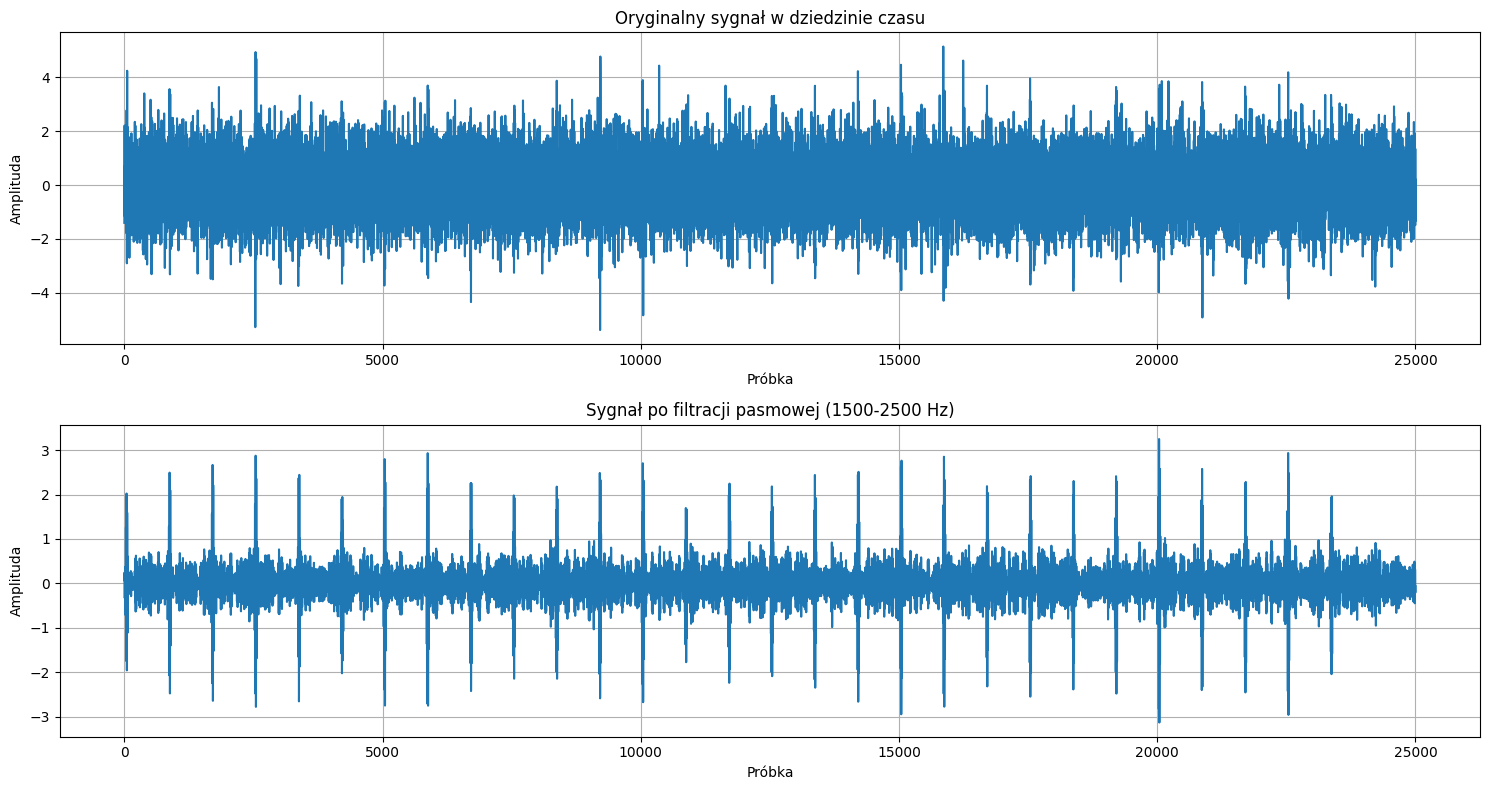

In [17]:
# Porównanie sygnałów w dziedzinie czasu
plt.figure(figsize=(15, 8))

# Oryginalny sygnał
plt.subplot(2, 1, 1)
plt.plot(signal)
plt.title('Oryginalny sygnał w dziedzinie czasu')
plt.xlabel('Próbka')
plt.ylabel('Amplituda')
plt.grid(True)

# Przefiltrowany sygnał
plt.subplot(2, 1, 2)
plt.plot(filtered_signal)
plt.title(f'Sygnał po filtracji pasmowej ({f_low}-{f_high} Hz)')
plt.xlabel('Próbka')
plt.ylabel('Amplituda')
plt.grid(True)

plt.tight_layout()
plt.show()

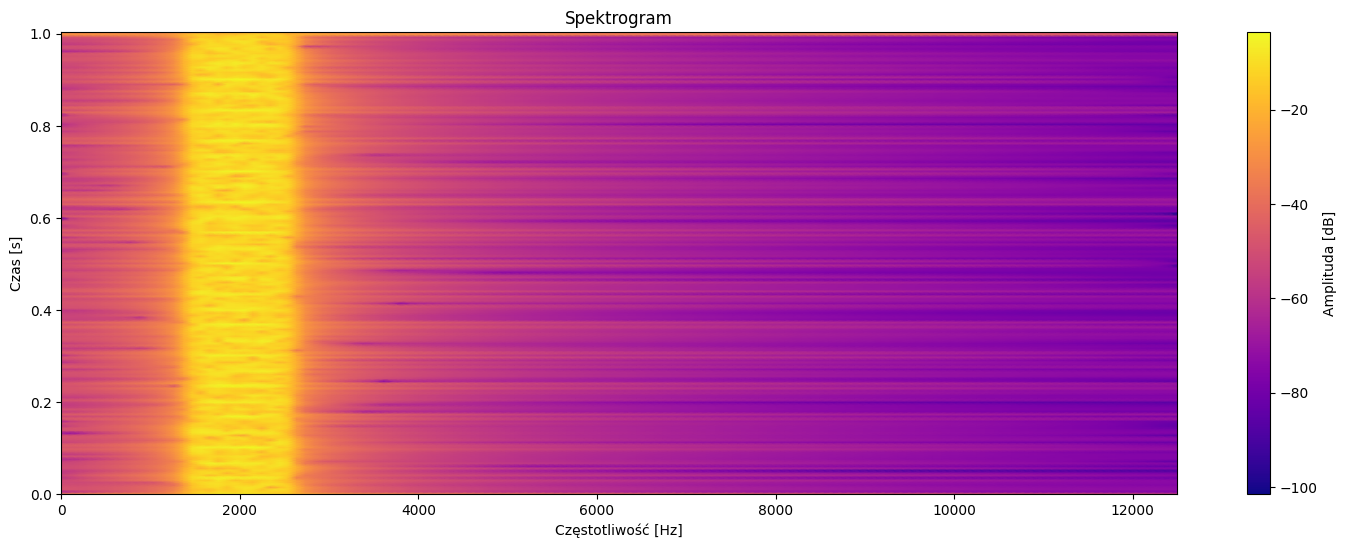

In [18]:
fs = 25000
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(filtered_signal, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
plt.figure(figsize=(18, 6))
plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram')
plt.colorbar(label='Amplituda [dB]')
plt.show()

In [5]:
import pandas as pd
df = pd.read_csv("website_fixed/app/uploads/gen_sig.csv", header = None)
print(df)
df[0].to_numpy()

              0
0      1.381723
1     -0.116326
2      0.514841
3     -0.103003
4     -0.190180
...         ...
24995 -1.448496
24996 -0.432910
24997  0.605103
24998  0.786117
24999 -0.739619

[25000 rows x 1 columns]


array([ 1.38172292, -0.11632646,  0.51484127, ...,  0.60510344,
        0.78611745, -0.73961858], shape=(25000,))